# Statistical Analysis
In this notebook we will do five statistical analysis.
1. Seasonality Test
2. National Correlation
3. Lag Analysis
4. Time Series Decomposition.
5. Comparative Analysis

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from scipy import stats
import warnings

# Initial setup
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

warnings.filterwarnings('ignore')

## 1. Seasonality Test
Does Malaria have a seasonal pattern ot its is just random variation.

### Null hypothesis (H0)
Cases are evenly distributed across months.

### Alternate hypothesis (H1)
Cases are not evenly distributed (sesonality exists.)

In [50]:
# Load clean data
reports = pd.read_csv('../data/processed/reports_clean.csv')

# Convert data types
reports['report_date'] = pd.to_datetime(reports['report_date'])
reports['case_date'] = pd.to_datetime(reports['case_date'])

category_cols = ['age_group', 'gender']
for col in category_cols:
    reports[col] = reports[col].astype('category')

# Add a month column
reports['month'] = reports['report_date'].dt.month

#### Test for seasonality on all diseases

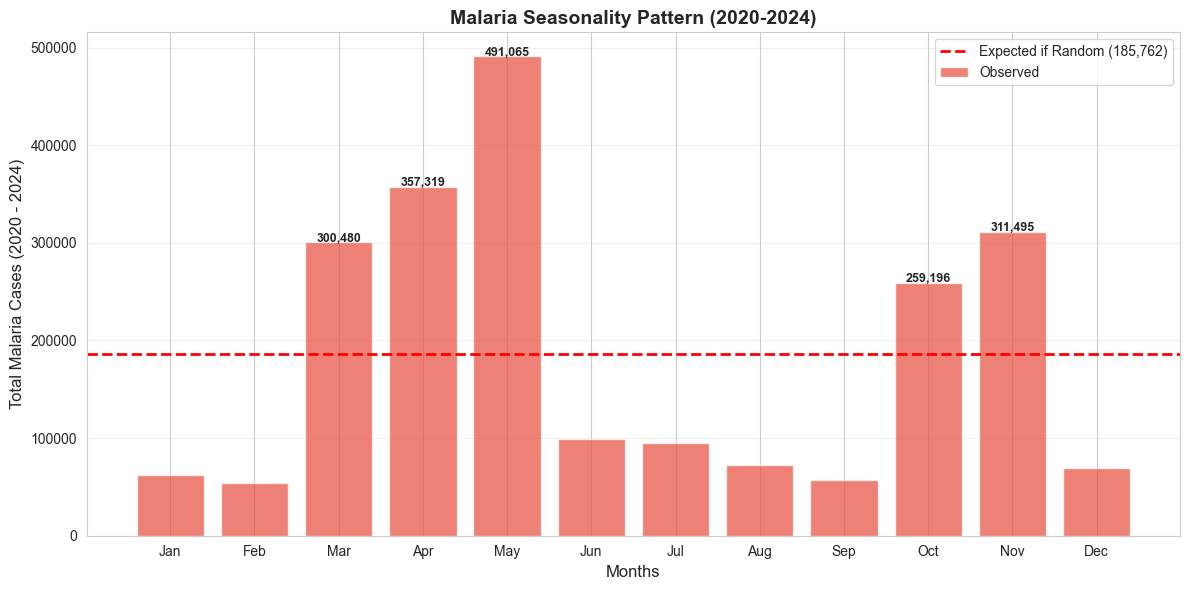

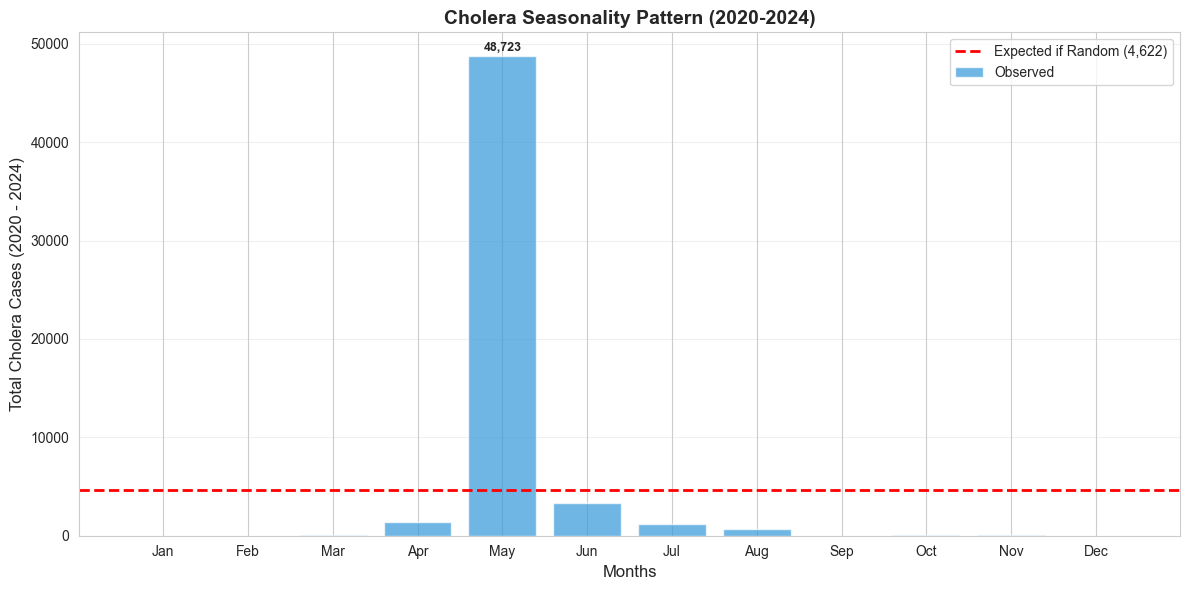

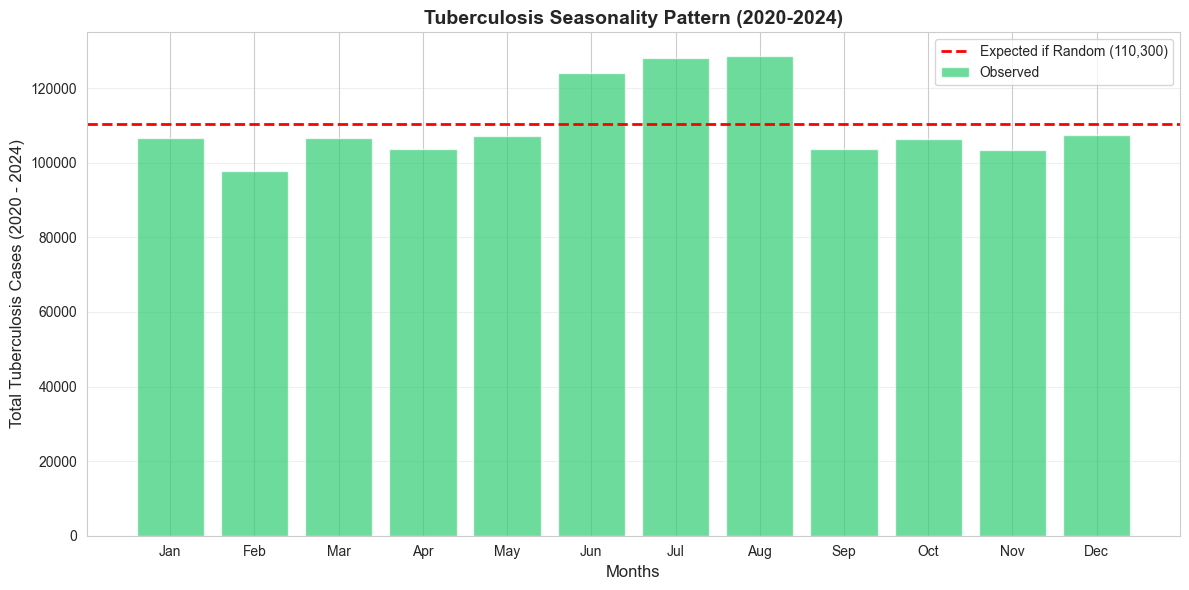

,Name of disease,Chi-Square,P-Value,Effect size,Significant,Effect
0,Malaria,1.336360e+06,0.0,0.233451,Yes,Moderate
1,Cholera,4.614004e+05,0.0,0.869666,Yes,Strong
2,Tuberculosis,1.080068e+04,0.0,0.027236,Yes,Negligible


In [52]:
diseases = ['Malaria', 'Cholera', 'Tuberculosis']
colors = ['#e74c3c', '#3498db', '#2ecc71']

results_summary = []

for i, disease in enumerate(diseases):
    disease_data = reports[reports['disease'] == disease]

    observations_per_month = disease_data.groupby('month')['new_cases'].sum()
    total = observations_per_month.sum()
    expected_observations = np.array([total / 12] * 12)
    fig, ax = plt.subplots(figsize=(12, 6))

    months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun','Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    ax.bar(months, observations_per_month.values, color=colors[i], alpha=0.7, label='Observed')

    ax.axhline(y=(total / 12), color='red', linestyle='--', 
            linewidth=2, label=f'Expected if Random ({(total / 12):,.0f})')

    ax.set_xlabel('Months', fontsize=12)
    ax.set_ylabel(f'Total {disease} Cases (2020 - 2024)', fontsize=12)
    ax.set_title(f'{disease} Seasonality Pattern (2020-2024)', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    for i, (month, count) in enumerate(zip(months, observations_per_month.values)):
        if count > (total / 12) * 1.3:
            ax.text(i, count + 500, f'{count:,.0f}', ha='center', fontsize=9, fontweight='bold')


    plt.tight_layout()
    plt.savefig(f'../src/images/{disease}_monthly_trends.png')
    plt.show()

    # chi_square test
    chi2, p_val = stats.chisquare(
        f_obs = observations_per_month.values,
        f_exp = expected_observations
    )

    # Effect size
    cramers = np.sqrt(chi2 / (total * 11))

    results_summary.append({
        'Name of disease': disease,
        'Chi-Square': chi2,
        'P-Value': p_val,
        'Effect size': cramers,
        'Significant': 'Yes' if p_val < 0.05 else 'No',
        'Effect': 'Strong' if cramers > 0.3 else 'Moderate' if cramers > 0.2 else 'Weak' if cramers > 0.1 else 'Negligible'
    })

results_summary_df = pd.DataFrame(results_summary)

results_summary_df